Analysis

In [1]:
#Imports libraries for data analysis and visualisation
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

#Ignores warning messages
import warnings; warnings.filterwarnings('ignore')

#Displays plots in the notebook
%matplotlib inline

#Imports utility functions
import utils

#Loads the dataset
df=utils.load_data()

#Displays the total snapshots and unique videos
print('snapshots',len(df),'unique videos',df.ytvideoid.nunique())

snapshots 200000 unique videos 11160


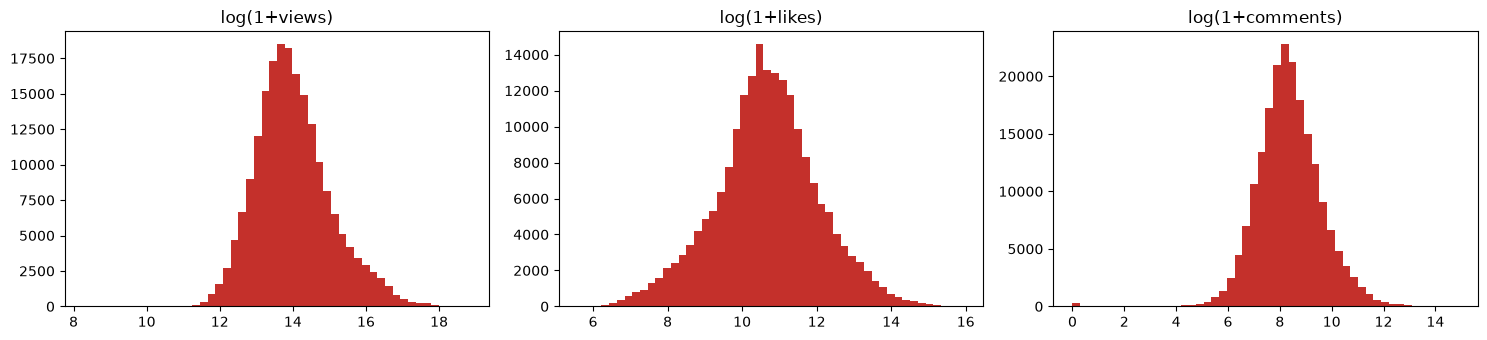

             views      likes   dislikes   comments
count     200000.0   200000.0   200000.0   200000.0
mean     2330972.0   113755.0     4498.0    10658.0
std      4743308.0   283033.0    72758.0    49489.0
min         3969.0      270.0        6.0        0.0
25%       604400.0    19034.0      471.0     1993.0
50%      1091419.0    42757.0     1024.0     4036.0
75%      2174954.0    99438.0     2513.0     8888.0
max    152598177.0  8516294.0  7026319.0  2918955.0


In [2]:
#Engagement distributions (log scale)
#Creates histograms for engagement metrics
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))

#Plots the log-transformed distributions
for a, c in zip(ax, ['views', 'likes', 'comments']):
    a.hist(np.log1p(df[c]), bins=50, color='#c4302b')
    a.set_title(f'log(1+{c})')

#Adjusts layout and display the plots
plt.tight_layout()
plt.show()

#Displays summary statistics
print(df[['views', 'likes', 'dislikes', 'comments']].describe().round(0).to_string())

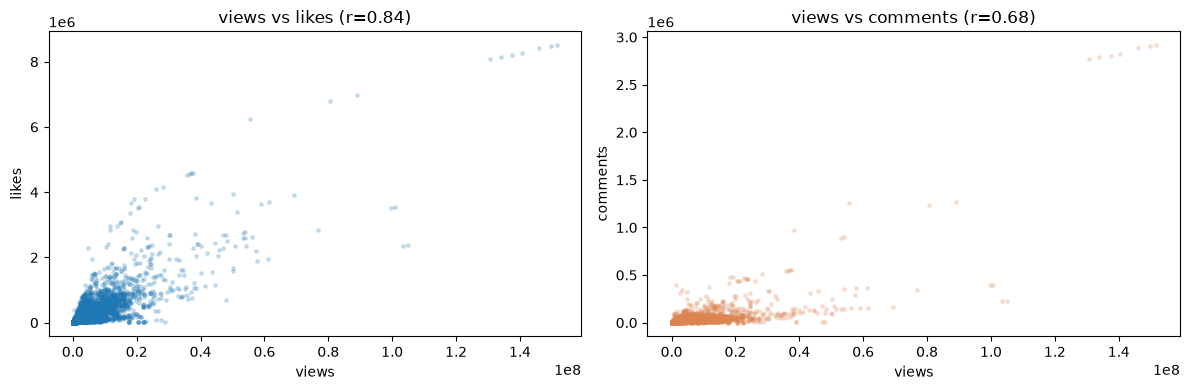

In [3]:
#Views vs Likes / Comments
# Select a random sample for plotting
s = df.sample(min(20000, len(df)), random_state=42)

# Create scatter plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot views against likes
ax[0].scatter(s.views, s.likes, alpha=0.2, s=6)
ax[0].set_xlabel('views')
ax[0].set_ylabel('likes')
ax[0].set_title(f'views vs likes (r={df.views.corr(df.likes):.2f})')

# Plot views against comments
ax[1].scatter(s.views, s.comments, alpha=0.2, s=6, color='#dd8452')
ax[1].set_xlabel('views')
ax[1].set_ylabel('comments')
ax[1].set_title(f'views vs comments (r={df.views.corr(df.comments):.2f})')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

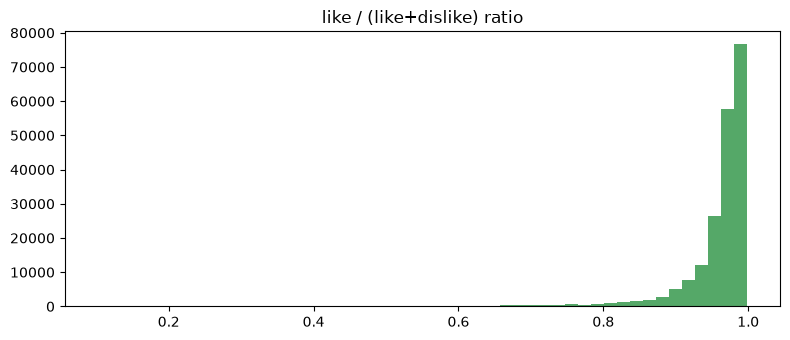

median like ratio: 0.976


In [4]:
#Audience Sentiment
# Calculate the like ratio
df['like_ratio'] = df['likes'] / (df['likes'] + df['dislikes'] + 1)

# Plot the distribution of like ratios
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(df['like_ratio'], bins=50, color='#55a868')
ax.set_title('like / (like+dislike) ratio')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Display the median like ratio
print('median like ratio: %.3f' % df['like_ratio'].median())

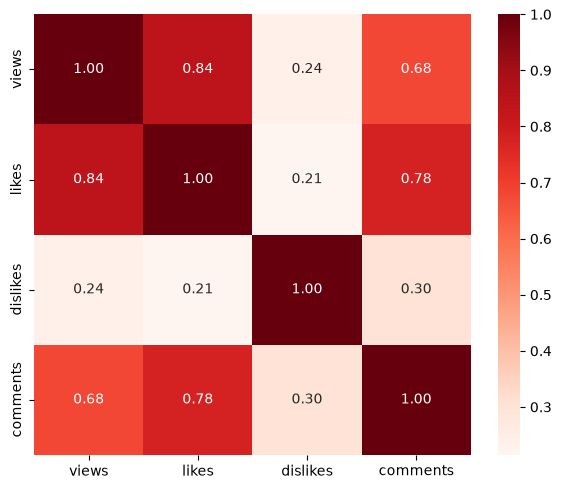

In [5]:
#Correlation heatmap
# Create a correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5))

# Display correlations between engagement metrics
sns.heatmap(
    df[['views', 'likes', 'dislikes', 'comments']].corr(),
    annot=True,
    fmt='.2f',
    cmap='Reds',
    ax=ax
)

# Adjust layout and display the heatmap
plt.tight_layout()
plt.show()

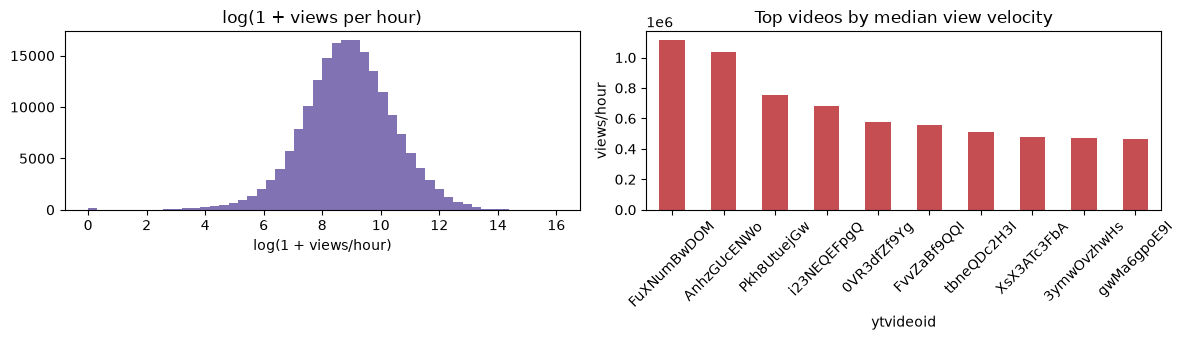

median view velocity: 7323 views/hour
90th percentile view velocity: 49971 views/hour


In [6]:
#View velocity: how fast are trending videos accumulating views?
vel = utils.add_view_velocity(df) #Add hours_since_prev, views_delta, views_per_hour to the dataframe
vel = vel[
    (vel["hours_since_prev"] > 0) & #Keep only rows with a positive time gap (removes first snapshot per video and duplicate timestamps)
    vel["views_per_hour"].notna() & #Drop rows where velocity could not be computed
    (vel["views_per_hour"] >= 0) #Keep only non-negative growth (remove any resets or drops in views)
]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5)) #Two side-by-side plots: velocity distribution and top videos

ax[0].hist(np.log1p(vel["views_per_hour"]), bins=50, color="#8172b3") #Histogram of log(1+velocity) because velocity is heavily right-skewed
ax[0].set_title("log(1 + views per hour)") #Title for the distribution plot
ax[0].set_xlabel("log(1 + views/hour)") #X-axis label

counts = vel.groupby("ytvideoid")["views_per_hour"].count() #Count how many valid velocity snapshots each video has
stable = vel[vel["ytvideoid"].isin(counts[counts >= 3].index)] #Keep only videos with at least 3 snapshots so their median is meaningful
top_vel = stable.groupby("ytvideoid")["views_per_hour"].median().sort_values(ascending=False).head(10) #Fastest videos: median velocity per video, only videos with 3+ snapshots, top 10

top_vel.plot(kind="bar", ax=ax[1], color="#c44e52") #Bar chart of the 10 fastest videos by median velocity
ax[1].set_title("Top videos by median view velocity") #Title for the top-videos plot
ax[1].set_ylabel("views/hour") #Y-axis label
ax[1].tick_params(axis="x", rotation=45) #Rotate video IDs on the x-axis so they are readable

plt.tight_layout() #Adjust spacing so titles and labels do not overlap
plt.show() #Render the figure

print("median view velocity: %.0f views/hour" % vel["views_per_hour"].median()) #Typical views gained per hour across all snapshots
print("90th percentile view velocity: %.0f views/hour" % vel["views_per_hour"].quantile(0.90)) #How fast the top 10% of snapshots are growing

Key Insights

- The dataset contains over 200,000 engagement snapshots from approximately 11,000 trending YouTube videos.
- Views and likes show a strong positive correlation, indicating that highly viewed videos typically receive proportionally more likes.
- Comments increase with view count but exhibit greater variability than likes.
- Audience sentiment is overwhelmingly positive, with a median like ratio close to 98%.
- Engagement metrics are heavily right-skewed, suggesting a small number of viral videos dominate total interactions.
- View velocity: between consecutive snapshots, median view growth is 7323 views/hour; the 90th percentile is 49971 views/hour. A small set of videos grow much faster, reinforcing the bursty nature of trending content.